<a href="https://colab.research.google.com/github/souhaib-coder/souhaib-coder/blob/main/LogistiqueRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

import pandas as pd

n = 100


np.random.seed(1)
p1 = np.random.uniform(0, 1, n)

p2 = np.random.uniform(2, 3, n)
x = np.array([p1, p2]).reshape((-1, 1))

y = np.repeat([0, 1], [n, n], axis=0)

In [ ]:
data=np.hstack((x,y.reshape(-1, 1)))
df=pd.DataFrame(data)

In [ ]:
print(df[1].unique().size)

2


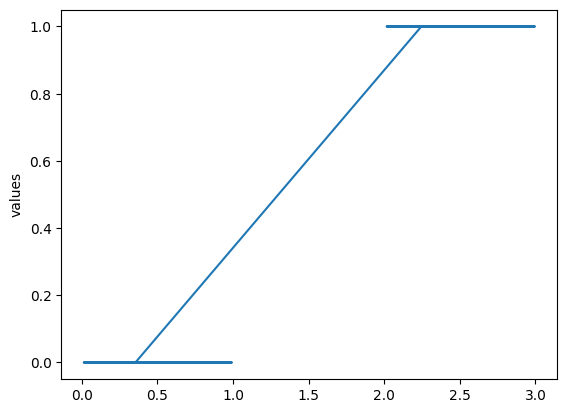

In [ ]:
import matplotlib.pyplot as plt

plt.plot(x,y)

plt.ylabel("values")

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
logistique = LogisticRegression(penalty=None, solver="newton-cg")

logistique.fit(x,y)

LogisticRegression(penalty=None, solver='newton-cg')

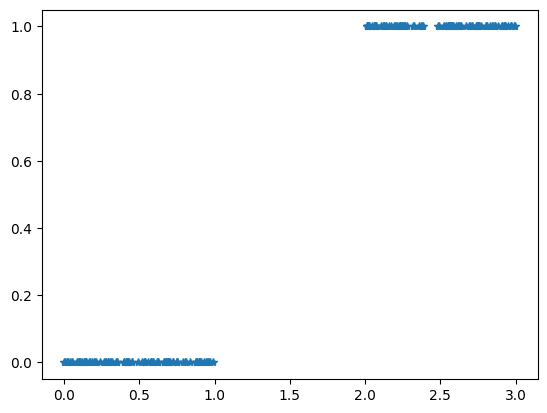

Prediction:  [1]


In [ ]:
#Interpréter les résultats de la commande

#Etape N4: Visualisation du modèle proposé

from scipy.special import expit

def sig(coef, intercept):
    axes = plt.gca()
    tmp = np.array(axes.get_xlim())
    xvals = np.linspace(tmp[0],tmp[1],100)
    y_vals = xvals * coef + intercept
    sigmoid = expit(y_vals)
    plt.plot(xvals, sigmoid.ravel(), c="green", label = "logistic fit")
    plt.plot(x,y,'*')

sig(logistique.coef_[0], logistique.intercept_[0])

plt.show()

#Etape N°5: Prédictions

#Prédiction de la valeur yi qui correspond à xi=100

valeur_x=np.array([100]).reshape((-1, 1))

valeur_y=logistique.predict(valeur_x)
print("Prediction: ", valeur_y)

mon modele


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [ ]:
x, y = make_classification(n_samples=200,n_features=2,n_redundant=0,n_clusters_per_class=1,random_state=42)

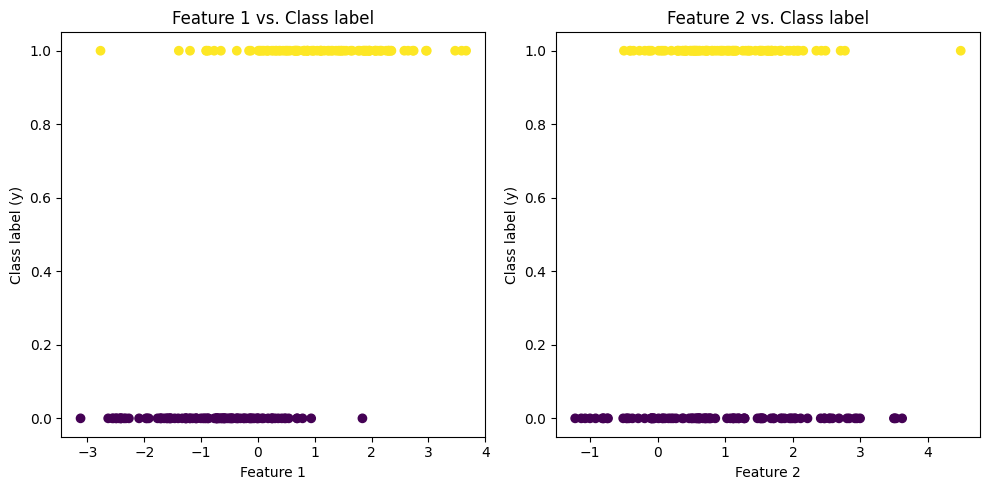

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], y, c=y)
plt.xlabel('Feature 1')
plt.ylabel('Class label (y)')
plt.title('Feature 1 vs. Class label')

plt.subplot(1, 2, 2)
plt.scatter(x[:, 1], y, c=y)
plt.xlabel('Feature 2')
plt.ylabel('Class label (y)')
plt.title('Feature 2 vs. Class label')

plt.tight_layout()
plt.show()

In [ ]:
def initData(x,y):
  y=y.reshape(-1,1)
  x=np.hstack((x,np.ones((x.shape[0],1))))
  theta=np.random.randn(x.shape[1],1)
  return x,y,theta

In [ ]:
def logisticModel(X,Theta):
  return 1/(1+np.exp(-X.dot(Theta)))

In [ ]:
def costFunction(X,Y,Theta):
  expression1=(Y.T).dot(np.log(logisticModel(X,Theta)))
  expression2=(1-Y.T).dot(np.log(1-logisticModel(X,Theta)))
  return (-1/X.shape[0])*(expression1+expression2)

In [ ]:
X,Y,Theta=initData(x,y)

In [ ]:
costFunction(X,Y,Theta)

array([[1.01331239]])

In [ ]:
model=logisticModel(X,Theta)

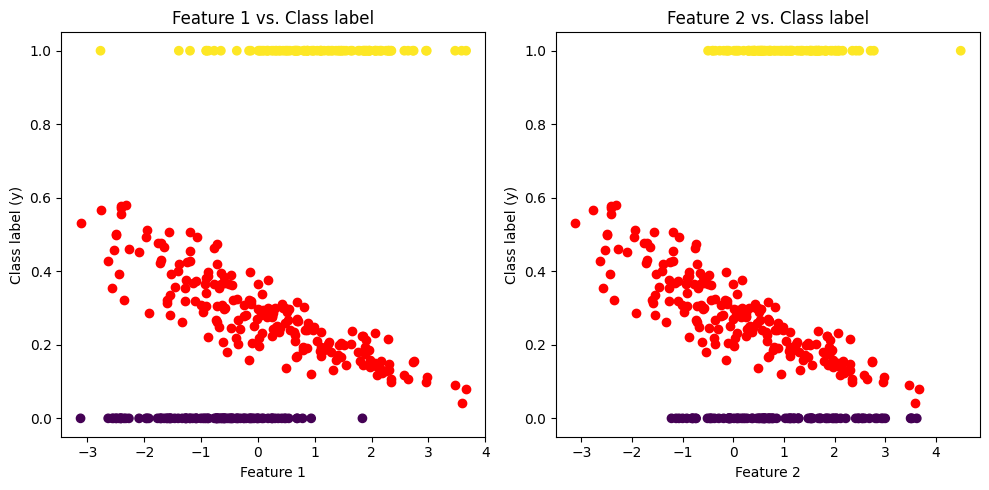

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], y, c=y)
plt.scatter(x[:, 0], model, color="red")
plt.xlabel('Feature 1')
plt.ylabel('Class label (y)')
plt.title('Feature 1 vs. Class label')

plt.subplot(1, 2, 2)
plt.scatter(x[:, 1], y, c=y)
plt.scatter(x[:, 0], model,color="red")
plt.xlabel('Feature 2')
plt.ylabel('Class label (y)')
plt.title('Feature 2 vs. Class label')

plt.tight_layout()
plt.show()

In [ ]:
def gradient(X,Y,Theta):
  return (1/X.shape[0])*(X.T).dot(logisticModel(X,Theta)-Y)

In [ ]:
def hessien(X,Y,Theta):
  m=logisticModel(X,Theta)
  R=np.diag((m*(1-m)).ravel())
  return (1/X.shape[0])*(X.T)@R@X

In [ ]:
def newtonMethod(X,Y,Theta,n_iteration):
  cost_history = np.zeros(n_iteration)
  for i in range(n_iteration):
    cost_history[i] =costFunction(X,Y,Theta)
    Theta=Theta-np.linalg.inv(hessien(X,Y,Theta))@gradient(X,Y,Theta)
  return Theta, cost_history

In [ ]:
optimumeTheta,cost=newtonMethod(X,Y,Theta,10)

/tmp/ipython-input-2456778865.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cost_history[i] =costFunction(X,Y,Theta)


In [ ]:
def plot_cost_function(nombre_iteration,cost):
  plt.plot(range(nombre_iteration),cost)
  plt.xlabel("iteration")
  plt.ylabel("J(theta)")

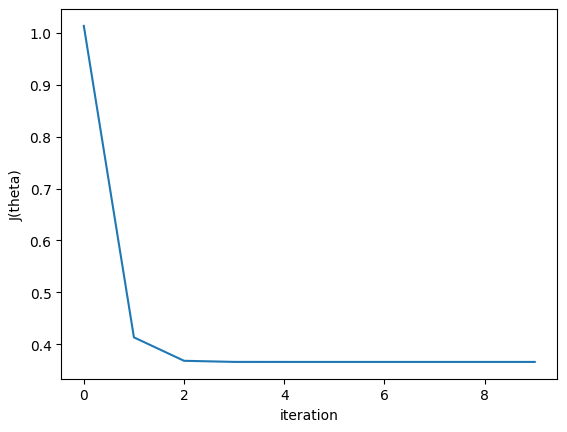

In [ ]:
plot_cost_function(10,cost)

In [ ]:
# Probabilités prédites
y_pred_proba = logisticModel(X, optimumeTheta)

# Classes prédites
y_pred = (y_pred_proba >= 0.5).astype(int)


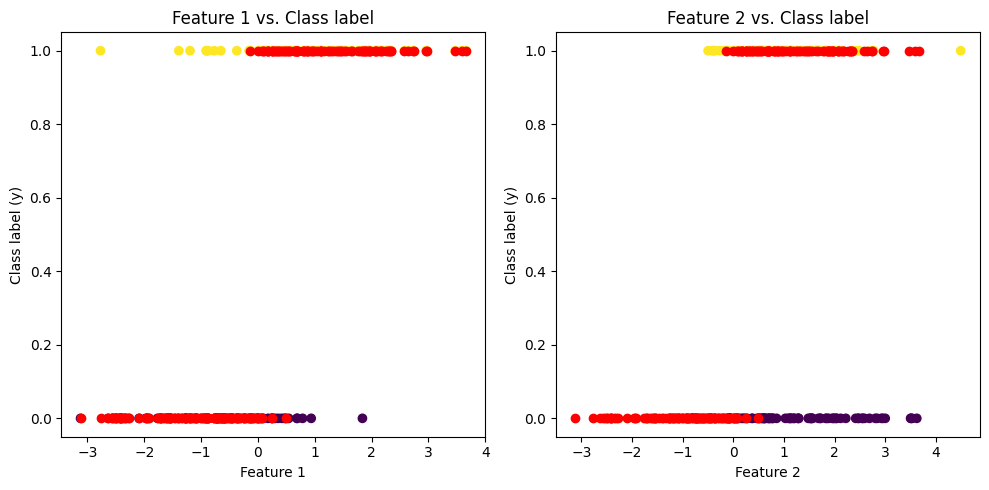

In [ ]:
M=logisticModel(X,optimumeTheta)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], y, c=y)
plt.scatter(x[:, 0], y_pred, color="red")
plt.xlabel('Feature 1')
plt.ylabel('Class label (y)')
plt.title('Feature 1 vs. Class label')

plt.subplot(1, 2, 2)
plt.scatter(x[:, 1], y, c=y)
plt.scatter(x[:, 0], y_pred,color="red")
plt.xlabel('Feature 2')
plt.ylabel('Class label (y)')
plt.title('Feature 2 vs. Class label')

plt.tight_layout()
plt.show()

In [ ]:
costFunction(X,Y,optimumeTheta)

array([[0.36592305]])

In [ ]:
def visualisation(X, y, Theta):
  resolution = 300
  fig, ax = plt.subplots(figsize=(9, 6))
  ax.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k')

  #limites du graphique
  xlim = ax.get_xlim()
  ylim = ax.get_ylim()

  # meshgrid
  x1 = np.linspace(xlim[0], xlim[1], resolution)
  x2 = np.linspace(ylim[0], ylim[1], resolution)
  X1, X2 = np.meshgrid(x1, x2)

  # assembler les 2 variables and add intercept term
  XX = np.vstack((X1.ravel(), X2.ravel())).T
  XX = np.hstack((XX, np.ones((XX.shape[0], 1)))) # Add intercept term

  # Prédictions (using logisticModel and thresholding)
  Z = logisticModel(XX, Theta)
  Z = (Z > 0.5).astype(int) # Threshold at 0.5 for classification
  Z = Z.reshape((resolution, resolution))

  ax.pcolormesh(X1, X2, Z, zorder=0, alpha=0.1)
  ax.contour(X1, X2, Z, colors='g')

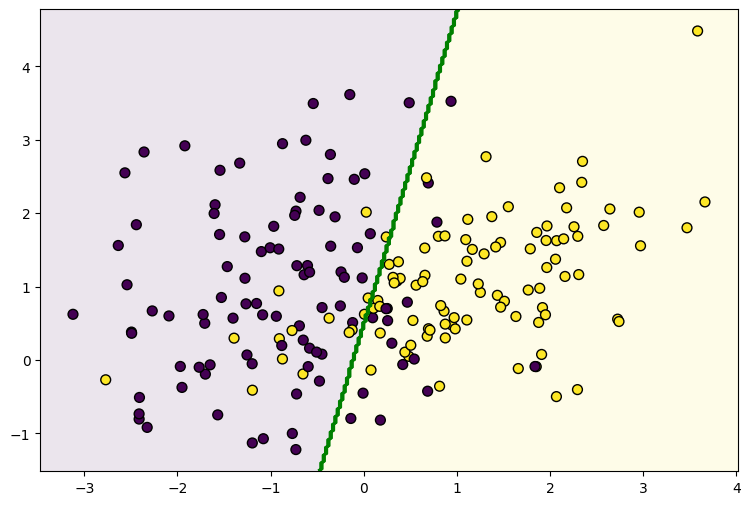

In [ ]:
visualisation(X, y,optimumeTheta)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(Y, y_pred))
print("\nMatrice de confusion :\n", confusion_matrix(Y, y_pred))
print("\nRapport de classification :\n", classification_report(Y, y_pred))


Accuracy : 0.84

Matrice de confusion :
 [[83 17]
 [15 85]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.85      0.83      0.84       100
           1       0.83      0.85      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200

